In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Plant Disease Detection-2']


In [3]:
import os

print(os.listdir("/content/drive/MyDrive/Plant Disease Detection-2"))

['app.py', 'README.md', 'requirements.txt', 'dataset']


In [4]:
import os

print(os.listdir("/content/drive/MyDrive/Plant Disease Detection-2/dataset"))

['archive (3).zip']


### Copy ZIP to Colab local storage

In [5]:
!cp "/content/drive/MyDrive/Plant Disease Detection-2/dataset/archive (3).zip" /content/

### Unzip

In [6]:
!unzip -q "/content/archive (3).zip" -d /content/

### Check extracted folders

In [7]:
import os

print(os.listdir("/content"))

['.config', 'PlantVillage', 'archive (3).zip', 'drive', 'sample_data']


### Check inside the extracted folder

In [8]:
import os

DATA_PATH = "/content/PlantVillage"

folders = os.listdir(DATA_PATH)

print("Total folders:", len(folders))
print(folders[:10])

Total folders: 2
['val', 'train']


### Check number of classes

In [9]:
classes = [
    f for f in os.listdir(DATA_PATH)
    if os.path.isdir(os.path.join(DATA_PATH, f))
]

print("Number of classes:", len(classes))

Number of classes: 2


### Count images

In [10]:
from pathlib import Path

count = 0

for img in Path(DATA_PATH).rglob("*"):
    if img.suffix.lower() in [".jpg",".jpeg",".png"]:
        count += 1

print("Total Images:", count)

Total Images: 54305


### Check train structure

In [11]:
import os

TRAIN_PATH = "/content/PlantVillage/train"
VAL_PATH = "/content/PlantVillage/val"

print("Train folders:")
print(os.listdir(TRAIN_PATH)[:10])

print("\nTotal train classes:", len(os.listdir(TRAIN_PATH)))

print("\nValidation folders:")
print(os.listdir(VAL_PATH)[:10])

print("\nTotal validation classes:", len(os.listdir(VAL_PATH)))

Train folders:
['Tomato___healthy', 'Grape___healthy', 'Pepper,_bell___Bacterial_spot', 'Potato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___healthy', 'Strawberry___healthy', 'Raspberry___healthy']

Total train classes: 38

Validation folders:
['Tomato___healthy', 'Grape___healthy', 'Pepper,_bell___Bacterial_spot', 'Potato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___healthy', 'Strawberry___healthy', 'Raspberry___healthy']

Total validation classes: 38


### Create Dataset

In [12]:
from torchvision import datasets

TRAIN_PATH = "/content/PlantVillage/train"
VAL_PATH = "/content/PlantVillage/val"

train_dataset = datasets.ImageFolder(TRAIN_PATH)
val_dataset = datasets.ImageFolder(VAL_PATH)

print(train_dataset.classes == val_dataset.classes)

True


### Create Transform

In [13]:
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

transform = weights.transforms()

### Reload Dataset with Transform

In [14]:
train_dataset = datasets.ImageFolder(
    TRAIN_PATH,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    VAL_PATH,
    transform=transform
)

### Create DataLoaders

In [36]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

### Verify

In [37]:
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("Classes:", len(train_dataset.classes))

print(train_dataset.classes == val_dataset.classes)

Train images: 43444
Validation images: 10861
Classes: 38
True


### Select Device

In [38]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


### Build ResNet18 Model

In [39]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

### Freeze the Backbone

In [40]:
for param in model.parameters():
    param.requires_grad = False

### Replace the Final Layer

In [41]:
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes

)

In [42]:
model = model.to(device)

### Verify the Model

In [43]:
print(model.fc)

Linear(in_features=512, out_features=38, bias=True)


### Loss Function

In [44]:
criterion = nn.CrossEntropyLoss()

### Optimizer

In [45]:
optimizer = torch.optim.Adam(model.fc.parameters(),
                             lr = 0.001)

### Learning Rate Scheduler

In [46]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

### Verify Everything

In [47]:
print("Device:", device)
print("Train Classes:", len(train_dataset.classes))
print("Validation Classes:", len(val_dataset.classes))
print("Same Mapping:", train_dataset.classes == val_dataset.classes)
print(model.fc)

Device: cuda
Train Classes: 38
Validation Classes: 38
Same Mapping: True
Linear(in_features=512, out_features=38, bias=True)


### Training Function

In [48]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

### Validation Function

In [49]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        progress_bar = tqdm(loader, desc="Validation")

        for images, labels in progress_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

### Initialize Variables

In [50]:
EPOCHS = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0.0

### Training Loop

In [51]:
for epoch in range(EPOCHS):

    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("="*60)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nTrain Loss      : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")

    print(f"Validation Loss      : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.2f}%")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), "best_plant_disease_model.pth")

        print("\n Best model saved!")


Epoch 1/10


Training:   0%|          | 0/679 [00:00<?, ?it/s]

Validation:   0%|          | 0/170 [00:00<?, ?it/s]


Train Loss      : 0.6719
Train Accuracy : 85.13%
Validation Loss      : 0.2587
Validation Accuracy : 93.87%

 Best model saved!

Epoch 2/10


Training:   0%|          | 0/679 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/170 [00:00<?, ?it/s]


Train Loss      : 0.0934
Train Accuracy : 97.12%
Validation Loss      : 0.1193
Validation Accuracy : 96.22%

 Best model saved!

Epoch 10/10


Training:   0%|          | 0/679 [00:00<?, ?it/s]

Validation:   0%|          | 0/170 [00:00<?, ?it/s]


Train Loss      : 0.0876
Train Accuracy : 97.33%
Validation Loss      : 0.1199
Validation Accuracy : 96.30%

 Best model saved!


### Load the Best Model

In [52]:
import torch

model.load_state_dict(torch.load("best_plant_disease_model.pth"))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Generate Predictions on the Validation Set

In [53]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
y_true = []
y_pred = []

with torch.no_grad():

  for images, labels in val_loader:

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs,1)

    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())

print("Predicted completed!")
print("Total validation samples:", len(y_true))


Predicted completed!
Total validation samples: 10861


### Confusion matrix

In [54]:
cm = confusion_matrix(y_true, y_pred)

print(cm.shape)

(38, 38)


### Classification Report

In [57]:
print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes,
    digits=4
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9313    0.9683    0.9494       126
                                 Apple___Black_rot     0.9685    0.9840    0.9762       125
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        55
                                   Apple___healthy     0.9671    0.9818    0.9744       329
                               Blueberry___healthy     0.9934    0.9967    0.9950       300
          Cherry_(including_sour)___Powdery_mildew     0.9952    0.9857    0.9904       210
                 Cherry_(including_sour)___healthy     0.9941    0.9941    0.9941       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8295    0.7087    0.7644       103
                       Corn_(maize)___Common_rust_     1.0000    0.9791    0.9894       239
               Corn_(maize)___Northern_Leaf_Blight     0.8645    0.9391    0.90

### Visualize the Confusion Matrix

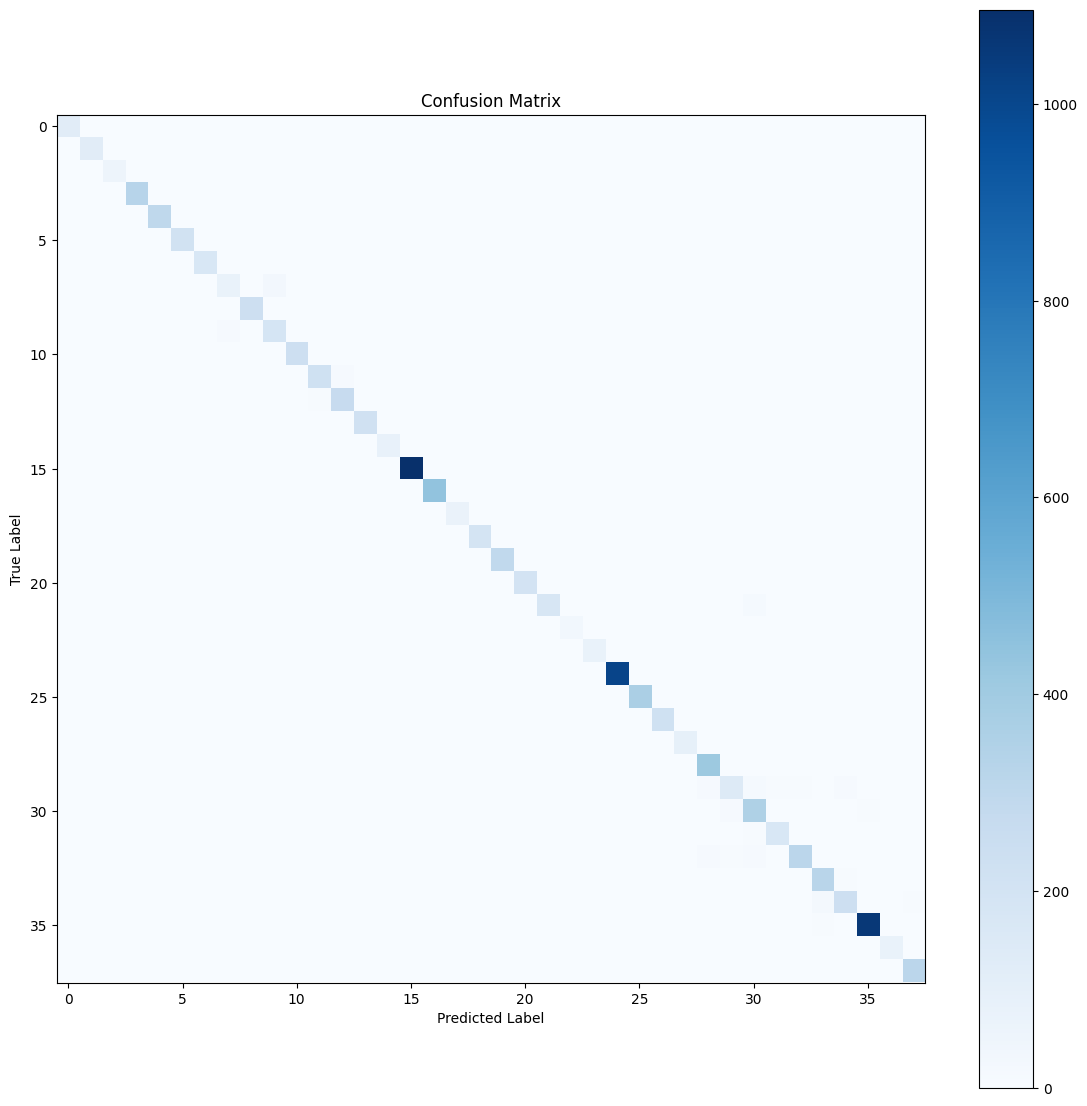

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 14))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Accuracy & Loss Graphs

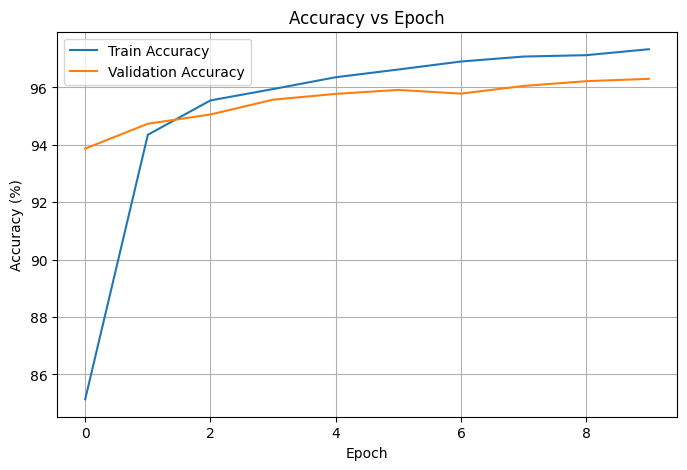

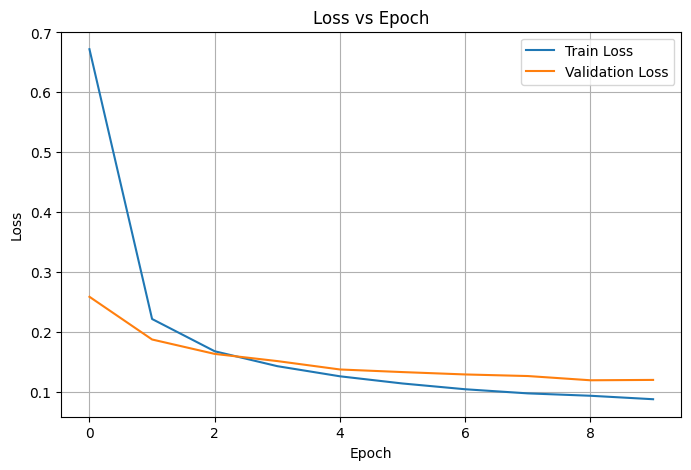

In [60]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Save the Class Names

In [61]:
class_names = train_dataset.classes

print(class_names)
print("Total Classes:", len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

### Load a Test Image

In [67]:
from google.colab import files

uploaded = files.upload()

Saving 0d3c0790-7833-470b-ac6e-94d0a3bf3e7c___FREC_Scab 2959.JPG to 0d3c0790-7833-470b-ac6e-94d0a3bf3e7c___FREC_Scab 2959.JPG
Saving 3f369e63-81eb-4194-a145-df9ed91abc5d___RS_HL 1745.JPG to 3f369e63-81eb-4194-a145-df9ed91abc5d___RS_HL 1745.JPG
Saving 4bbccfb6-5720-4c80-9b37-0c3ed8999c9f___RS_HL 1791.JPG to 4bbccfb6-5720-4c80-9b37-0c3ed8999c9f___RS_HL 1791.JPG
Saving 5fcbde8f-52af-4963-b324-ff7f4dd6bd4c___RS_HL 1762.JPG to 5fcbde8f-52af-4963-b324-ff7f4dd6bd4c___RS_HL 1762.JPG


### Preprocess the Image

In [71]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    img = transform(image)
    img = img.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(img)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

    disease = class_names[predicted.item()]

    print(f"Predicted Disease : {disease}")
    print(f"Confidence        : {confidence.item()*100:.2f}%")

### Predict  Image

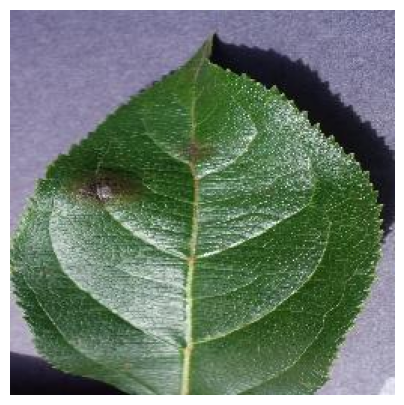

Predicted Disease : Apple___Apple_scab
Confidence        : 66.67%


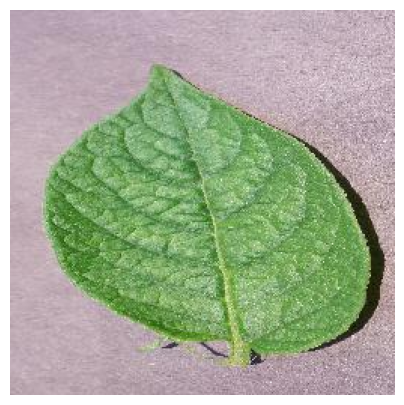

Predicted Disease : Potato___healthy
Confidence        : 99.65%


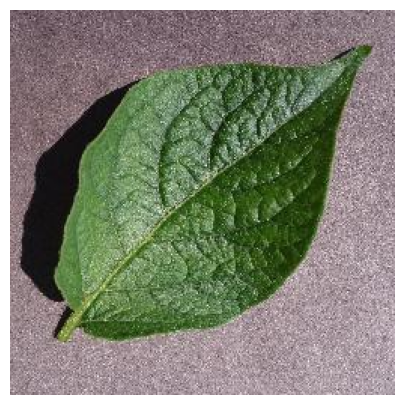

Predicted Disease : Potato___healthy
Confidence        : 68.96%


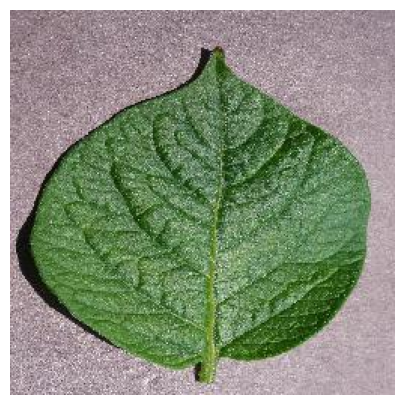

Predicted Disease : Potato___healthy
Confidence        : 99.06%


In [74]:
predict_image("/content/0d3c0790-7833-470b-ac6e-94d0a3bf3e7c___FREC_Scab 2959.JPG")
predict_image("/content/3f369e63-81eb-4194-a145-df9ed91abc5d___RS_HL 1745.JPG")
predict_image("/content/4bbccfb6-5720-4c80-9b37-0c3ed8999c9f___RS_HL 1791.JPG")
predict_image("/content/5fcbde8f-52af-4963-b324-ff7f4dd6bd4c___RS_HL 1762.JPG")

### Save the complete model

In [75]:
torch.save(model.state_dict(), "plant_disease_resnet18.pth")

In [76]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names
}, "plant_disease_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [77]:
from google.colab import files

files.download("plant_disease_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 102.6 MB/s eta 0:00:00


In [79]:
%%writefile app.py

Writing app.py


In [80]:
import streamlit as st
import torch
import torch.nn as nn
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights
from torchvision import transforms
from PIL import Image

# ============================
# Page Configuration
# ============================

st.set_page_config(
    page_title="Plant Disease Detection",
    page_icon="🌿",
    layout="centered"
)

st.title("🌿 Plant Disease Detection using ResNet18")

st.write(
    "Upload a plant leaf image to predict the disease."
)

# ============================
# Device
# ============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================
# Load Checkpoint
# ============================

@st.cache_resource
def load_model():

    checkpoint = torch.load(
        "plant_disease_model.pth",
        map_location=device
    )

    class_names = checkpoint["class_names"]

    model = resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        len(class_names)
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.to(device)

    model.eval()

    return model, class_names


model, class_names = load_model()

# ============================
# Image Transform
# ============================

weights = ResNet18_Weights.DEFAULT

transform = weights.transforms()

# ============================
# Upload Image
# ============================

uploaded_file = st.file_uploader(
    "Choose a Leaf Image",
    type=["jpg", "jpeg", "png"]
)

# ============================
# Prediction
# ============================

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Leaf Image",
        use_container_width=True
    )

    image_tensor = transform(image)

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

    disease = class_names[predicted.item()]

    confidence = confidence.item() * 100

    st.success(f"Predicted Disease: {disease}")

    st.info(f"Confidence: {confidence:.2f}%")

    st.progress(min(int(confidence), 100))

# ============================
# Footer
# ============================

st.markdown("---")

st.markdown(
    """
    ### Project Details

    - Model : ResNet18 (Transfer Learning)
    - Framework : PyTorch
    - Dataset : PlantVillage
    - Number of Classes : 38
    """
)

2026-10-09 14:06:34.854 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-09 14:06:34.855 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-09 14:06:34.976 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-10-09 14:06:34.977 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-09 14:06:34.978 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-09 14:06:34.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-09 14:06:34.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [156]:
 01de6e24-61b0-4a33-90d8-0b2e7fe93305.JPG
'0d3c0790-7833-470b-ac6e-94d0a3bf3e7c___FREC_Scab 2959.JPG'
 1ac2fcfb-92ad-4fda-9aa7-7e4450af6647.JPG
 1e2d9fa6-886a-4d54-8b50-6f3eb9d446d0.JPG
 2e9e8a6a-74d4-4331-a6ec-37df8f320198.JPG
 3d260242-9465-4977-83eb-0f41c9682aa0.JPG
 3e8f6fba-2de5-447a-8996-1cf3a18f72dd.JPG
'3f369e63-81eb-4194-a145-df9ed91abc5d___RS_HL 1745.JPG'
'4bbccfb6-5720-4c80-9b37-0c3ed8999c9f___RS_HL 1791.JPG'
'5fcbde8f-52af-4963-b324-ff7f4dd6bd4c___RS_HL 1762.JPG'
 app.py
'archive (3).zip'
 best_plant_disease_model.pth
 drive
 plant_disease_model.pth
 plant_disease_resnet18.pth
 PlantVillage
 sample_data
 streamlit.log

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (780170939.py, line 1)